In [15]:
# Basic Libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import pydot
import seaborn as sns

#Evaluation library
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV


import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
#from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
#from keras.wrappers.scikit_learn import KerasClassifier




# Deep Learning libraries
#import tensorflow as tf
#from tensorflow.keras import layers

#from keras.models import Sequential
#from keras.layers.core import Dense,Activation,Dropout
#from keras.datasets import mnist
#from keras.utils.np_utils import to_categorical
#from keras.wrappers.scikit_learn import KerasClassifier

In [14]:

pip install keras


Note: you may need to restart the kernel to use updated packages.


In [2]:
#!pip install tensorflow==2.7.0

In [16]:
#Digit MNIST dataset
(X_train_digit, y_train_digit), (X_test_digit, y_test_digit) = mnist.load_data()

In [17]:
X_train_digit[1]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  51, 159, 253, 159,  50,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  48, 238, 252, 252, 252, 237,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [18]:
y_train_digit

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

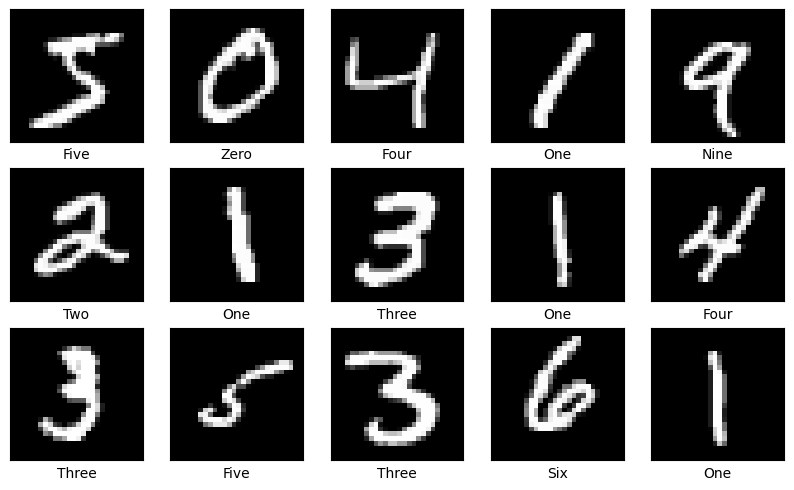

In [19]:
#Names of numbers in the dataset in order
col_names = ['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']

#Visualizing the digits
plt.figure(figsize=(10,10))
for i in range(15):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train_digit[i], cmap='gray')
    plt.xlabel(col_names[y_train_digit[i]])
plt.show()

In [20]:
X_train_digit.shape

(60000, 28, 28)

In [21]:
X_train_digit = X_train_digit.reshape(60000, 784)
X_test_digit = X_test_digit.reshape(10000, 784)

In [22]:
X_train_digit.shape

(60000, 784)

In [23]:
y_test_digit.shape

(10000,)

In [24]:
#Encoding Digit MNIST Labels
y_train_digit = to_categorical(y_train_digit, num_classes=10)

y_test_digit = to_categorical(y_test_digit, num_classes=10)

In [25]:
y_train_digit[1]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [26]:
#Creating base neural network
model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    #layers.Dropout(0.3),
    #layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    #layers.Dropout(0.3),
    #layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    #layers.Dropout(0.3),
    #layers.BatchNormalization(),
    layers.Dense(10,activation='sigmoid'),
])

C:\Users\USER\anaconda3\envs\AI_Project\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
#param_number = output_channel_number * (input_channel_number + 1)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 222,218 (868.04 KB)

 Trainable params: 222,218 (868.04 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
#Compiling the model
model.compile(loss="categorical_crossentropy",
              optimizer="adam",
              metrics = ['accuracy'])

In [29]:
history=model.fit(X_train_digit, y_train_digit, batch_size=100, epochs=10,validation_data=(X_test_digit, y_test_digit))

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7509 - loss: 4.3448 - val_accuracy: 0.9055 - val_loss: 0.3621
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9182 - loss: 0.3106 - val_accuracy: 0.9296 - val_loss: 0.2705
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9434 - loss: 0.2052 - val_accuracy: 0.9460 - val_loss: 0.2354
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9561 - loss: 0.1599 - val_accuracy: 0.9523 - val_loss: 0.2001
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9631 - loss: 0.1328 - val_accuracy: 0.9557 - val_loss: 0.1849
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9652 - loss: 0.1226 - val_accuracy: 0.9553 - val_loss: 0.1878
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9694 - loss: 0.1044 - val_accuracy: 0.9585 - val_loss: 0.1736
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9725 - loss: 0.0964 - val_accuracy: 0.

In [30]:
#Predicting the labels-DIGIT
y_predict = model.predict(X_test_digit)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [31]:
y_predict[0]

array([8.2688850e-01, 1.3697540e-02, 9.9443233e-01, 9.7759521e-01,
       4.0686941e-01, 9.9554628e-01, 6.9504476e-06, 9.9999809e-01,
       9.1008836e-01, 9.9416399e-01], dtype=float32)

In [32]:
y_predicts=np.argmax(y_predict, axis=1) # Here we get the index of maximum value in the encoded vector


In [33]:
y_predicts

array([7, 1, 1, ..., 4, 5, 6], dtype=int64)

In [34]:
y_test_digit_eval=np.argmax(y_test_digit, axis=1)

In [35]:
y_test_digit_eval

array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

In [44]:
pip install seaborn


   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   - -------------------------------------- 0.5/15.8 MB 8.2 MB/s eta 0:00:02
   -- ------------------------------------- 1.0/15.8 MB 3.3 MB/s eta 0:00:05
   --- ------------------------------------ 1.3/15.8 MB 2.8 MB/s eta 0:00:06
   --- ------------------------------------ 1.6/15.8 MB 2.3 MB/s eta 0:00:07
   ---- ----------------------------------- 1.8/15.8 MB 2.1 MB/s eta 0:00:07
   ----- ---------------------------------- 2.1/15.8 MB 1.8 MB/s eta 0:00:08
   ----- ---------------------------------- 2.1/15.8 MB 1.8 MB/s eta 0:00:08
   ----- ---------------------------------- 2.4/15.8 MB 1.4 MB/s eta 0:00:10
   ----- ---------------------------------- 2.4/15.8 MB 1.4 MB/s eta 0:00:10
   ------ --------------------------------- 2.6/15.8 MB 1.2 MB/s eta 0:00:11
   ------ --------------------------------- 2.6/15.8 MB 1.2 MB/s eta 0:00:11
   ------- --

In [45]:
#Confusion matrix for Digit MNIST
import matplotlib.pyplot as plt

con_mat=confusion_matrix(y_test_digit_eval,y_predicts)
plt.style.use('seaborn-deep')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot=True,annot_kws={'size': 15},linewidths=0.5,fmt="d",cmap="gray")
plt.title('True or False predicted digit MNIST\n',fontweight='bold',fontsize=15)
plt.show()

OSError: 'seaborn-deep' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test_digit_eval,y_predicts))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.82      0.99      0.90      1135
           2       0.90      0.92      0.91      1032
           3       0.69      0.95      0.80      1010
           4       0.77      0.81      0.79       982
           5       0.89      0.59      0.71       892
           6       0.97      0.64      0.77       958
           7       0.99      0.93      0.96      1028
           8       0.95      0.95      0.95       974
           9       0.96      0.92      0.94      1009

    accuracy                           0.88     10000
   macro avg       0.89      0.87      0.87     10000
weighted avg       0.89      0.88      0.87     10000



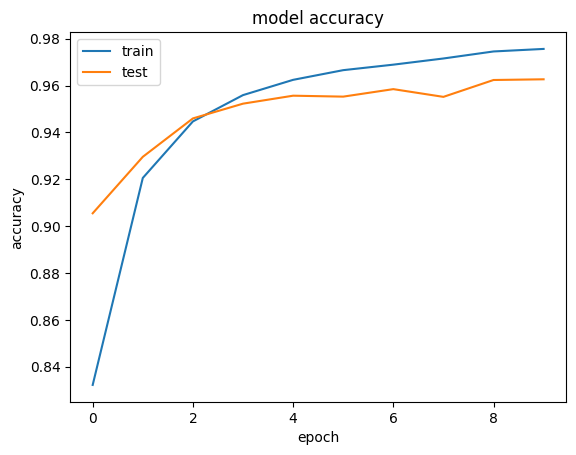

In [39]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()


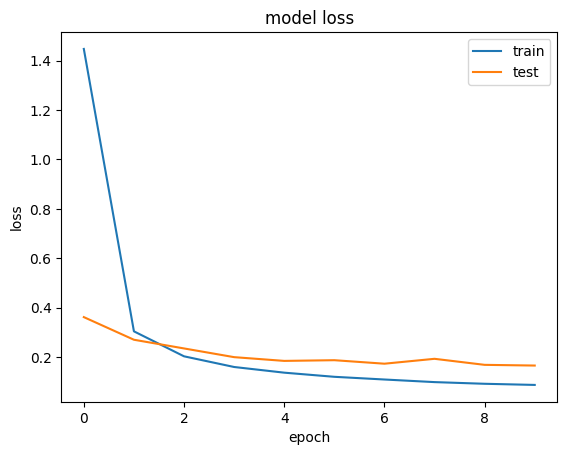

In [40]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

In [41]:
#tf.expand_dims(X_test_digit[0])
y_predict_single = model.predict(X_test_digit[[2]])
y_predicts_single=np.argmax(y_predict_single, axis=1) # Here we get the index of maximum value in the encoded vector
y_test_digit_eval=np.argmax(y_test_digit, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


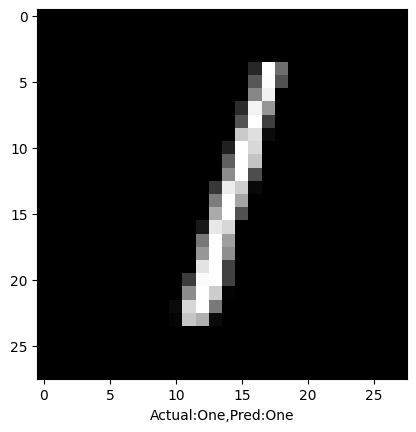

In [42]:
#Names of numbers in the dataset in order
col_names = ['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']

#Visualizing the digits
#plt.figure(figsize=(10,10))
plt.imshow(X_test_digit[2].reshape(28,28), cmap='gray')
plt.xlabel("Actual:{},Pred:{}".format(col_names[np.argmax(y_test_digit[2])],col_names[y_predicts_single[0]]))
plt.show()